# Frequentist Inference Case Study - Part B

## Learning objectives

Welcome to Part B of the Frequentist inference case study! The purpose of this case study is to help you apply the concepts associated with Frequentist inference in Python. In particular, you'll practice writing Python code to apply the following statistical concepts: 
* the _z_-statistic
* the _t_-statistic
* the difference and relationship between the two
* the Central Limit Theorem, including its assumptions and consequences
* how to estimate the population mean and standard deviation from a sample
* the concept of a sampling distribution of a test statistic, particularly for the mean
* how to combine these concepts to calculate a confidence interval

In the previous notebook, we used only data from a known normal distribution. **You'll now tackle real data, rather than simulated data, and answer some relevant real-world business problems using the data.**

## Hospital medical charges

Imagine that a hospital has hired you as their data scientist. An administrator is working on the hospital's business operations plan and needs you to help them answer some business questions. 

In this assignment notebook, you're going to use frequentist statistical inference on a data sample to answer the questions:
* has the hospital's revenue stream fallen below a key threshold?
* are patients with insurance really charged different amounts than those without?

Answering that last question with a frequentist approach makes some assumptions, and requires some knowledge, about the two groups.

We are going to use some data on medical charges obtained from [Kaggle](https://www.kaggle.com/easonlai/sample-insurance-claim-prediction-dataset). 

For the purposes of this exercise, assume the observations are the result of random sampling from our single hospital. Recall that in the previous assignment, we introduced the Central Limit Theorem (CLT), and its consequence that the distributions of sample statistics approach a normal distribution as $n$ increases. The amazing thing about this is that it applies to the sampling distributions of statistics that have been calculated from even highly non-normal distributions of data! Recall, also, that hypothesis testing is very much based on making inferences about such sample statistics. You're going to rely heavily on the CLT to apply frequentist (parametric) tests to answer the questions in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from scipy import stats
from numpy.random import seed
medical = pd.read_csv('insurance2.csv')

In [2]:
medical.shape

(1338, 8)

In [3]:
medical.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


__Q1:__ Plot the histogram of charges and calculate the mean and standard deviation. Comment on the appropriateness of these statistics for the data.

__A:__

Mean of medical charges : 13270.422265141257
Standard Deviation of medical charges : 12110.011236693994


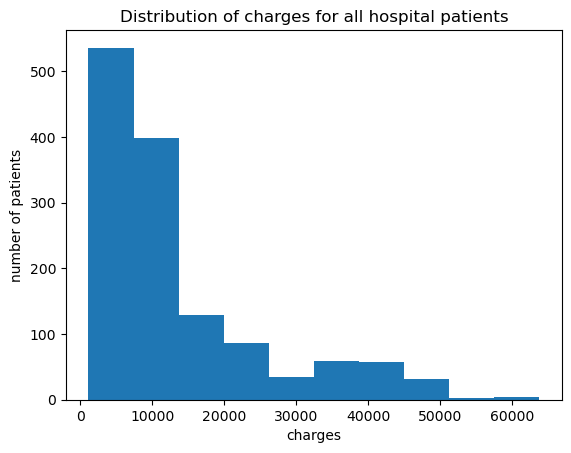

In [4]:
_ = plt.hist(medical["charges"])
_ = plt.xlabel('charges')
_ = plt.ylabel('number of patients')
_ = plt.title('Distribution of charges for all hospital patients')
medical_mean = np.mean(medical["charges"])
medical_stddev = np.std(medical["charges"], ddof =1)
print(f"Mean of medical charges : {medical_mean}")
print(f"Standard Deviation of medical charges : {medical_stddev}")

Since, the distribution is heavily right skewed (not normally distributed) with most of the charges upto around 15,000 mark, the mean and standard deviation will not be the best statistics to represent this data distribution. 

__Q2:__ The administrator is concerned that the actual average charge has fallen below 12,000, threatening the hospital's operational model. On the assumption that these data represent a random sample of charges, how would you justify that these data allow you to answer that question? And what would be the most appropriate frequentist test, of the ones discussed so far, to apply?

__A:__ We can justify using this random sample of charges data to estimate the population mean with the help of Central Limit Theorem which states that the sample distribution of the mean will follow a normal distribution for large sample sizes even if the underlying population distribution is not normal. In our case, the sample size is 1338 which is large enough to justify the use of frequentist inference method despite the skewness of individual data points.

The most  appropriate frequentist test would be a t test since the population stanadard deviation is not known.

__Q3:__ Given the nature of the administrator's concern, what is the appropriate confidence interval in this case? A ***one-sided*** or ***two-sided*** interval? (Refresh your understanding of this concept on p. 399 of the *AoS*). Calculate the critical value and the relevant 95% confidence interval for the mean, and comment on whether the administrator should be concerned.

__A:__

The appropriate confidence interval is this case would be one sided since the administrator is concerned about the average charge falling below a certain thresholf of 12000.

In [5]:
t_critical = t.ppf(0.95, 1338-1)
margin_of_error = t_critical*(medical_stddev/np.sqrt(1338))
cfi_lb = medical_mean - margin_of_error
print(margin_of_error)
print(cfi_lb)

544.9350813250251
12725.48718381623


The administrator should not be concerned since the lower bound for the 95% confidence interval is 12725 which is much above 12000 and hence the data suggests that average charge has not fallen below 12000 which is the administrator's concern.

The administrator then wants to know whether people with insurance really are charged a different amount to those without.

__Q4:__ State the null and alternative hypothesis here. Use the _t_-test for the difference between means, where the pooled standard deviation of the two groups is given by:
\begin{equation}
s_p = \sqrt{\frac{(n_0 - 1)s^2_0 + (n_1 - 1)s^2_1}{n_0 + n_1 - 2}}
\end{equation}

and the *t*-test statistic is then given by:

\begin{equation}
t = \frac{\bar{x}_0 - \bar{x}_1}{s_p \sqrt{1/n_0 + 1/n_1}}.
\end{equation}

(If you need some reminding of the general definition of ***t-statistic***, check out the definition on p. 404 of *AoS*). 

What assumption about the variances of the two groups are we making here?

__A:__ 
Null Hypothesis : There is no difference in the amount charged to people with insurance and without insurance mean1 = mean2

Alternate Hypothesis : There is a considerable difference in the amount charged to people with insurance and without insurance mean1 <> mean2

__Q5:__ Perform this hypothesis test both manually, using the above formulae, and then using the appropriate function from [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html#statistical-tests) (hint, you're looking for a function to perform a _t_-test on two independent samples). For the manual approach, calculate the value of the test statistic and then its probability (the p-value). Verify you get the same results from both.

__A:__ 

In [14]:
insured = medical.loc[medical["insuranceclaim"] == 1,'charges']
uninsured = medical.loc[medical["insuranceclaim"] == 0,'charges']
n0 = len(medical.loc[medical["insuranceclaim"] == 1,'charges'])
x0 = np.mean(medical.loc[medical["insuranceclaim"] == 1,'charges'])
s0 = np.std(medical.loc[medical["insuranceclaim"] == 1,'charges'], ddof = 1)
n1 = len(medical.loc[medical["insuranceclaim"] == 0,'charges'])
x1 = np.mean(medical.loc[medical["insuranceclaim"] == 0,'charges'])
s1 = np.std(medical.loc[medical["insuranceclaim"] == 0,'charges'], ddof = 1)
print(f"insured_sample_size: {n0}")
print(f"insured_mean: {x0}")
print(f"insured_stddev: {s0}")
print(f"uninsured_sample_size: {n1}")
print(f"uninsured_mean: {x1}")
print(f"uninsured_stddev: {s1}")

insured_sample_size: 783
insured_mean: 16423.928276537677
insured_stddev: 14045.928418802127
uninsured_sample_size: 555
uninsured_mean: 8821.421892306305
uninsured_stddev: 6446.510126811736


In [7]:
#Manual Hypothesis Test
sp = np.sqrt(((n0-1)*s0**2 + (n1-1)*s1**2)/(n0+n1-2))
t = (x0-x1)/(sp*np.sqrt((1/n0) + (1/n1)))
print(f"pooled standard deviation: {sp}")
print(f"t statistic: {t}")
print(f"p value (since 11.89 is higher than any value in the t table for dof=1336 the p value is almost 0: ~0 ")

pooled standard deviation: 11520.034268775256
t statistic: 11.893299030876715
p value (since 11.89 is higher than any value in the t table for dof=1336 the p value is almost 0: ~0 


In [15]:
#Hypothesis Test using scipy stats
t_scipy, p_scipy = stats.ttest_ind(insured, uninsured, equal_var = True)
print(f"t statistic: {t_scipy}")
print(f"p value : {p_scipy}")

t statistic: 11.893299030876712
p value : 4.461230231620717e-31


We do see same t and p values using both methods!

Congratulations! Hopefully you got the exact same numerical results. This shows that you correctly calculated the numbers by hand. Secondly, you used the correct function and saw that it's much easier to use. All you need to do is pass your data to it.

__Q6:__ Conceptual question: look through the documentation for statistical test functions in scipy.stats. You'll see the above _t_-test for a sample, but can you see an equivalent one for performing a *z*-test from a sample? Comment on your answer.

__A:__ I do not see an equivalent z test from the sample in scipy.stats. I think it is missing because t test can be used for any sample size where te population variation is unknown. Also, for very large sample sizes t distribution would be very close to z distribution and would give a very similar result.

## Learning outcomes

Having completed this project notebook, you now have good hands-on experience:
* using the central limit theorem to help you apply frequentist techniques to answer questions that pertain to very non-normally distributed data from the real world
* performing inference using such data to answer business questions
* forming a hypothesis and framing the null and alternative hypotheses
* testing this using a _t_-test